In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Contexto del Proyecto

El objetivo de este proyecto es desarrollar y evaluar modelos de **regresión** capaces de predecir la variable objetivo `pobj`, derivada del proceso de optimización estructural representado en el conjunto de datos generado previamente.

El dataset contiene información sobre diferentes **experimentos numéricos** realizados con materiales bimateriales, con variables tales como `criterion`, `experiment`, `gray_level`, `problem_type`, `p`, `pmax` e `iteration`.  
Estas variables describen condiciones del modelo físico y de simulación que influyen en el valor final de `pobj` (función objetivo del diseño).

El entorno de trabajo está basado en **Python y scikit-learn**, con los datos procesados previamente en el EDA.  
El objetivo de esta etapa (Sprint 6) es comparar distintos enfoques de regresión, validar su desempeño mediante **cross-validation** y establecer una línea base sólida para iteraciones futuras.

---

### Variable objetivo (`pobj`)

- Representa la **capacidad portante óptima** o la **función objetivo** del problema de optimización.
- Es un **valor continuo**, ya que mide el rendimiento estructural máximo alcanzado en cada experimento.
- Se modela mediante **regresión**, porque se busca estimar el valor de `pobj` sin necesidad de resolver el problema completo cada vez.

---

### Variables predictoras

- `p`, `gray_level`, `problem_type`, `criterion`, `pmax`, `iteration`, `experiment`  
- Son **parámetros del problema de optimización** que influyen directamente en `pobj`.  
- Estas se utilizan como **features** para entrenar modelos predictivos.

---

### Métricas de evaluación

Se utilizarán las siguientes métricas, adecuadas para problemas de regresión continua:

- **MAE (Mean Absolute Error)** → Error promedio absoluto.  
- **RMSE (Root Mean Squared Error)** → Penaliza más los errores grandes.  
- **R² (Coeficiente de determinación)** → Evalúa la proporción de la varianza explicada por el modelo.


## Verificación de dataset y snapshot (Sprint 6)

In [ ]:
import os, time
import pandas as pd
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from datetime import datetime
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("drive/MyDrive/Week 6/results/eda_results.csv")

print(f"Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("Columnas:", list(df.columns))

with open("drive/MyDrive/Week 6/results/eda_results.csv", "rb") as f:
    file_hash = hashlib.md5(f.read()).hexdigest()

print(f"Snapshot hash del dataset: {file_hash}")
print("Fecha de verificación:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Dataset cargado correctamente: 209 filas y 8 columnas.
Columnas: ['experiment', 'iteration', 'pobj', 'p', 'gray_level', 'problem_type', 'criterion', 'pmax']
Snapshot hash del dataset: 1d77de92e8b91deee6f509142ffd8d7f
Fecha de verificación: 2025-10-22 23:00:33


## Recordatorio de Baseline

In [ ]:
X = df.drop(columns=['pobj', 'iteration'])
y = df['pobj']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(Cambiamos algunos modelos)

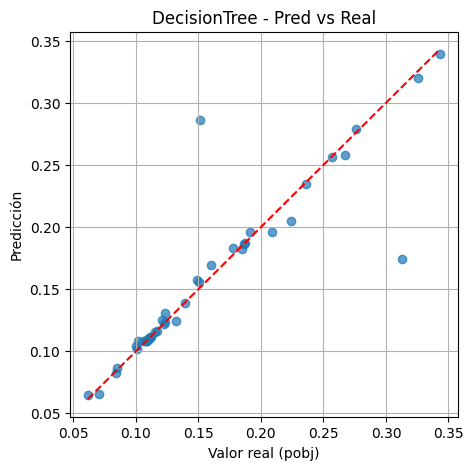

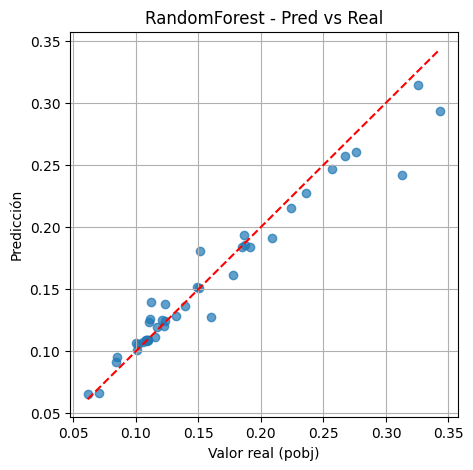

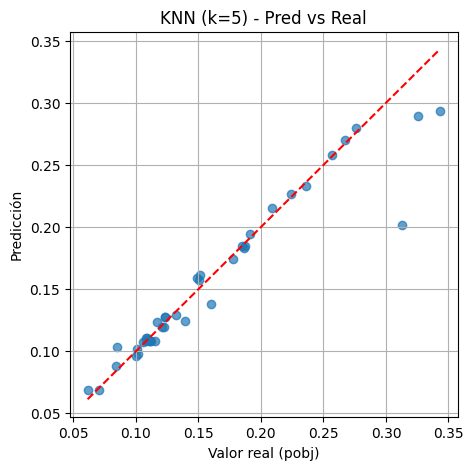

         Modelo       MAE      RMSE        R²
0  DecisionTree  0.009837  0.030292  0.814321
1  RandomForest  0.010292  0.017342  0.939142
2     KNN (k=5)  0.009024  0.020645  0.913755


In [ ]:
models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5)
}

results = []

for name, model in models.items():
    if "KNN" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(((y_test - y_pred) ** 2).mean())
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])

    plt.figure(figsize=(5,5))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Valor real (pobj)")
    plt.ylabel("Predicción")
    plt.title(f"{name} - Pred vs Real")
    plt.grid(True)
    plt.show()

results_df = pd.DataFrame(results, columns=["Modelo", "MAE", "RMSE", "R²"])
print(results_df)

## Experimentos A/B

En este sprint se realizaron pruebas comparativas (A/B) entre distintos modelos de regresión implementados con **scikit-learn**.  
El objetivo fue evaluar variantes más complejas o ajustadas frente a sus **versiones base (baseline)** y medir mejoras en desempeño y costo computacional.

---

### Modelos evaluados

**Baselines:**
- `KNN (k=5)`  
- `Decision Tree` (árbol simple)  
- `Random Forest (n=100)`  

**Variantes (A/B):**
- `KNN (k=9, distance)` — mayor vecindad y ponderación por distancia.  
- `Decision Tree (max_depth=10)` — límite de profundidad para evitar sobreajuste.  
- `Random Forest (n=200)` — aumento de árboles para mayor estabilidad.  
- `Gradient Boosting (n=200, lr=0.05)` — boosting secuencial para reducir sesgo.



## Resultados comparables

/tmp/ipython-input-3787672434.py:66: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()+"Z",
/tmp/ipython-input-3787672434.py:66: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()+"Z",
/tmp/ipython-input-3787672434.py:66: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()+"Z",
/tmp/ipython-input-3787672434.py:66: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a f

Resultados guardados en: drive/MyDrive/Week 6/results/experiments_sprint6/experiments_AB_results_with_RF_baseline.csv


/tmp/ipython-input-3787672434.py:66: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()+"Z",
/tmp/ipython-input-3787672434.py:66: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()+"Z",


,variant,baseline_compared,MAE,RMSE,R2,R2_vs_baseline_%,time_s
0,"Gradient Boosting (n=200, lr=0.05)",Random Forest (n=100),0.006442,0.010748,0.976624,3.223,0.1653
1,Random Forest (n=200),Random Forest (n=100),0.009489,0.015597,0.950772,0.491,0.3498
2,Random Forest (n=100),Random Forest (n=100),0.009886,0.016316,0.946129,0.000,0.1680
3,KNN (k=5),KNN (k=5),0.009024,0.020645,0.913755,0.000,0.0017
4,"KNN (k=9, distance)",KNN (k=5),0.012407,0.023774,0.885624,-3.079,0.0017
5,Decision Tree (max_depth=10),Decision Tree,0.009940,0.030256,0.814751,0.053,0.0023
6,Decision Tree,Decision Tree,0.009837,0.030292,0.814321,0.000,0.0020


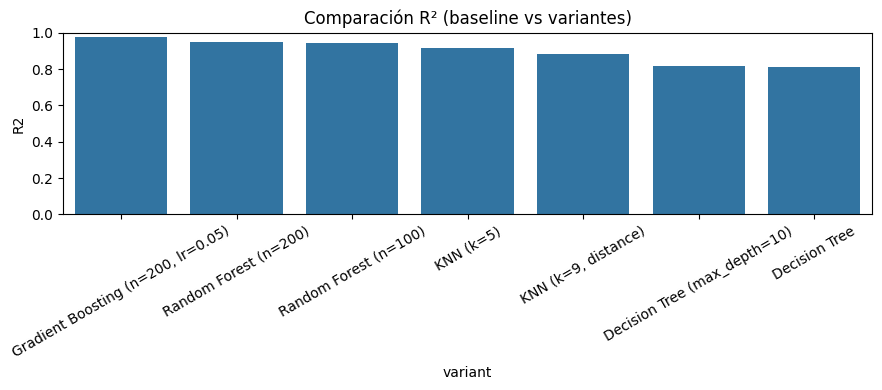

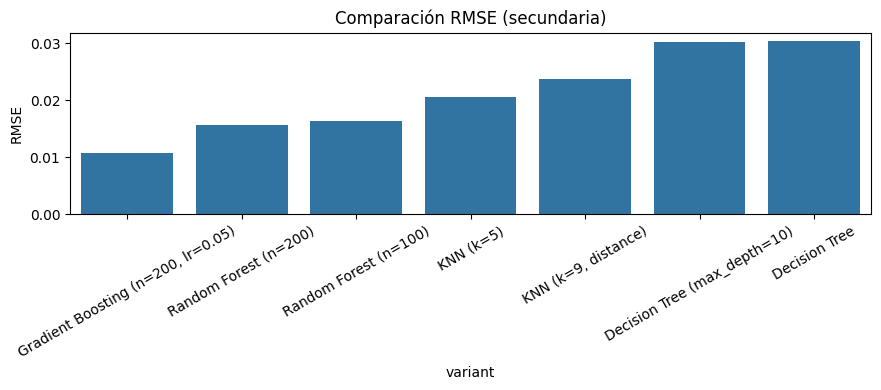

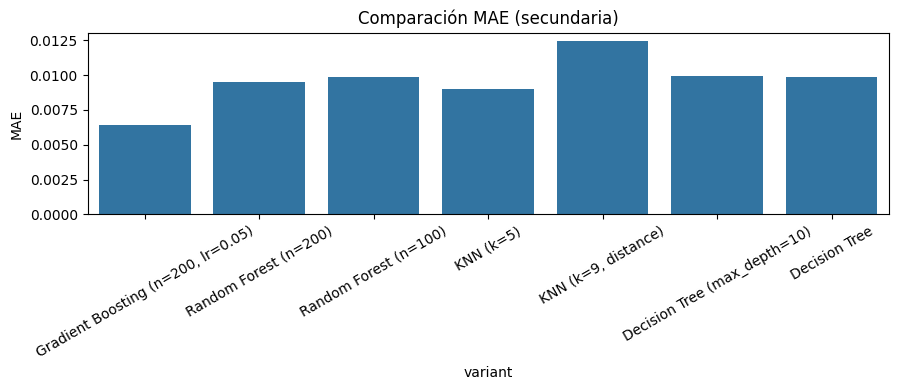

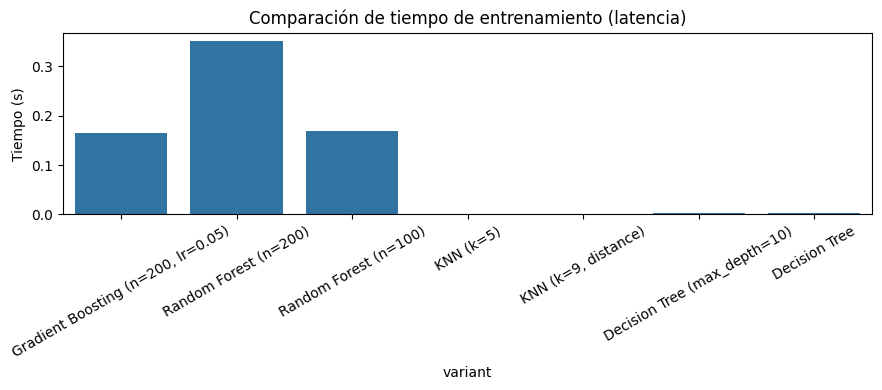

In [ ]:
CSV_PATH = "drive/MyDrive/Week 6/results/eda_results.csv"
OUT_DIR = "drive/MyDrive/Week 6/results/experiments_sprint6"
IMG_DIR = os.path.join(OUT_DIR, "images")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

TARGET = "pobj"
LEAK_COL = "iteration"
X = df.drop(columns=[TARGET, LEAK_COL])
y = df[TARGET]

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], remainder="drop")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor_fit = preprocessor.fit(X_train_raw)
X_train = preprocessor_fit.transform(X_train_raw)
X_test = preprocessor_fit.transform(X_test_raw)

models = {
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest (n=100)": RandomForestRegressor(n_estimators=100, random_state=42),

    "KNN (k=9, distance)": KNeighborsRegressor(n_neighbors=9, weights='distance'),
    "Decision Tree (max_depth=10)": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest (n=200)": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting (n=200, lr=0.05)": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

baseline_for = {
    "KNN (k=5)": "KNN (k=5)",
    "Decision Tree": "Decision Tree",
    "Random Forest (n=100)": "Random Forest (n=100)",

    "KNN (k=9, distance)": "KNN (k=5)",
    "Decision Tree (max_depth=10)": "Decision Tree",
    "Random Forest (n=200)": "Random Forest (n=100)",
    "Gradient Boosting (n=200, lr=0.05)": "Random Forest (n=100)"  # GB comparado con RF baseline
}

results = []
predictions = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - t0

    mae = mean_absolute_error(y_test, y_pred)
    rmse = float(np.sqrt(np.mean((y_test - y_pred)**2)))
    r2 = float(r2_score(y_test, y_pred))

    results.append({
        "timestamp": datetime.utcnow().isoformat()+"Z",
        "experiment": "Sprint6_AB_with_RF_baseline",
        "variant": name,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "time_s": float(round(elapsed, 4))
    })
    predictions[name] = (y_pred, y_test.values)

results_df = pd.DataFrame(results)

r2_map = results_df.set_index("variant")["R2"].to_dict()

baseline_name_col = []
improvements = []
for idx, row in results_df.iterrows():
    model_name = row["variant"]
    base_name = baseline_for.get(model_name, None)
    baseline_r2 = r2_map.get(base_name, None) if base_name is not None else None
    if baseline_r2 is None:
        improvement = np.nan
    else:
        improvement = ((row["R2"] - baseline_r2) / abs(baseline_r2)) * 100
    baseline_name_col.append(base_name if base_name is not None else "")
    improvements.append(improvement)

results_df["baseline_compared"] = baseline_name_col
results_df["R2_vs_baseline_%"] = [float(round(x, 3)) if not np.isnan(x) else x for x in improvements]

comp_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

csv_path = os.path.join(OUT_DIR, "experiments_AB_results_with_RF_baseline.csv")
comp_df.to_csv(csv_path, index=False)
print("Resultados guardados en:", csv_path)

display(comp_df[["variant", "baseline_compared", "MAE", "RMSE", "R2", "R2_vs_baseline_%", "time_s"]])

plt.figure(figsize=(9,4))
sns.barplot(data=comp_df, x="variant", y="R2", order=comp_df["variant"])
plt.title("Comparación R² (baseline vs variantes)")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cmp_R2_with_baseline.png"), dpi=150)
plt.show()

plt.figure(figsize=(9,4))
sns.barplot(data=comp_df, x="variant", y="RMSE", order=comp_df["variant"])
plt.title("Comparación RMSE (secundaria)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cmp_RMSE_with_baseline.png"), dpi=150)
plt.show()

plt.figure(figsize=(9,4))
sns.barplot(data=comp_df, x="variant", y="MAE", order=comp_df["variant"])
plt.title("Comparación MAE (secundaria)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cmp_MAE_with_baseline.png"), dpi=150)
plt.show()

plt.figure(figsize=(9,4))
sns.barplot(data=comp_df, x="variant", y="time_s", order=comp_df["variant"])
plt.title("Comparación de tiempo de entrenamiento (latencia)")
plt.ylabel("Tiempo (s)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "cmp_time_with_baseline.png"), dpi=150)
plt.show()

**Gráfico único**: Para visualizar la comparación global, se emplea un **Radar Plot**, donde cada eje
representa una métrica normalizada (R², RMSE, MAE y Tiempo) pues resume el desempeño global de cada modelo y comunica visualmente qué tan equilibradas son las mejoras de cada variante respecto al baseline.

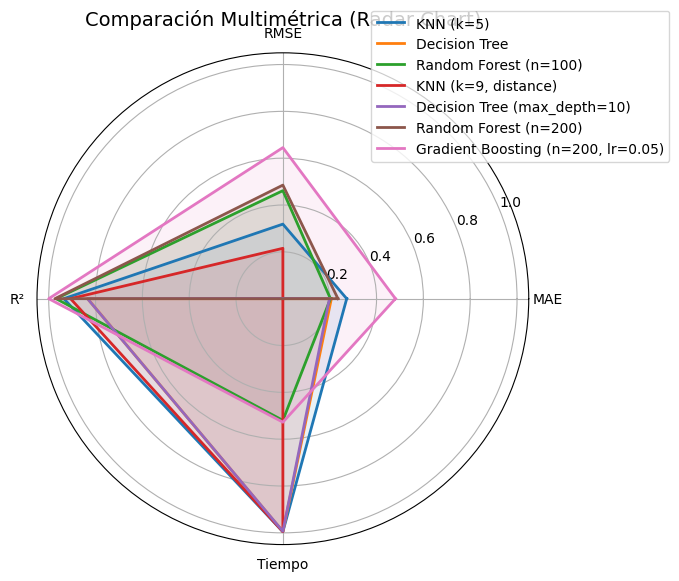

Radar chart guardado en: drive/MyDrive/Week 6/results/experiments_sprint6/images/unique_graph_radar.png


In [ ]:
df_radar = results_df.copy()
df_radar = df_radar.rename(columns={'variant': 'Modelo'})

df_radar['MAE_norm'] = 1 - (df_radar['MAE'] / df_radar['MAE'].max())
df_radar['RMSE_norm'] = 1 - (df_radar['RMSE'] / df_radar['RMSE'].max())
df_radar['R2_norm'] = df_radar['R2'] / df_radar['R2'].max()
df_radar['Time_norm'] = 1 - (df_radar['time_s'] / df_radar['time_s'].max())

metrics = ['MAE_norm', 'RMSE_norm', 'R2_norm', 'Time_norm']
labels = ['MAE', 'RMSE', 'R²', 'Tiempo']
num_vars = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for _, row in df_radar.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row['Modelo'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Comparación Multimétrica (Radar Chart)", size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

radar_path = os.path.join(IMG_DIR, "unique_graph_radar.png")
plt.savefig(radar_path, dpi=150)
plt.show()
print("Radar chart guardado en:", radar_path)



## Validación

Antes de seleccionar la variante final, se realiza una **validación cruzada (cross-validation)** para estimar la capacidad de generalización de cada modelo y reducir el riesgo de sobreajuste.

Se aplica un esquema de `KFold` con 5 particiones (`n_splits=5`), asegurando:

- **Sin data leakage:** el `ColumnTransformer` (escalado + codificación) se ajusta solo con los datos de entrenamiento.
- **Reproducibilidad:** se fija `random_state=42`.
- **Validación homogénea:** todos los modelos se evalúan bajo las mismas divisiones de los datos.

Las métricas promedio de validación serán:
- **MAE (Mean Absolute Error):** error absoluto medio.
- **RMSE (Root Mean Squared Error):** penaliza más los errores grandes.
- **R² (Coeficiente de determinación):** mide el grado de explicación de la varianza.


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'R2': make_scorer(r2_score)
}

models_cv = {
    "Random Forest (n=100)": RandomForestRegressor(n_estimators=100, random_state=42),
    "Random Forest (n=200)": RandomForestRegressor(n_estimators=200, random_state=42),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "KNN (k=9, distance)": KNeighborsRegressor(n_neighbors=9, weights='distance'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Decision Tree (max_depth=10)": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Gradient Boosting (n=200, lr=0.05)": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

cv_results = []

for name, model in models_cv.items():
    print(f"Validando {name}...")
    t0 = time.time()
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0

    cv_results.append({
        "Modelo": name,
        "MAE (CV)": np.mean(scores['test_MAE']),
        "RMSE (CV)": np.mean(scores['test_RMSE']),
        "R² (CV)": np.mean(scores['test_R2']),
        "Tiempo (s)": round(elapsed, 3)
    })

cv_df = pd.DataFrame(cv_results).sort_values("R² (CV)", ascending=False)
display(cv_df)

cv_df.to_csv("drive/MyDrive/Week 6/results/validation_results.csv", index=False)
print("Resultados de validación guardados correctamente.")

Validando Random Forest (n=100)...
Validando Random Forest (n=200)...
Validando KNN (k=5)...
Validando KNN (k=9, distance)...
Validando Decision Tree...
Validando Decision Tree (max_depth=10)...
Validando Gradient Boosting (n=200, lr=0.05)...


,Modelo,MAE (CV),RMSE (CV),R² (CV),Tiempo (s)
3,"KNN (k=9, distance)",0.007025,0.012247,0.964723,0.082
2,KNN (k=5),0.009016,0.014819,0.947770,0.069
6,"Gradient Boosting (n=200, lr=0.05)",0.008307,0.016024,0.930175,1.309
1,Random Forest (n=200),0.009538,0.019542,0.897502,2.300
0,Random Forest (n=100),0.009587,0.019420,0.896704,2.654
5,Decision Tree (max_depth=10),0.010278,0.025023,0.806448,0.073
4,Decision Tree,0.010051,0.024778,0.804232,0.102


Resultados de validación guardados correctamente.


## Selección de la variante final

Tras realizar la validación cruzada (5-fold CV), se compararon las métricas promedio de desempeño y el tiempo de entrenamiento de todas las variantes candidatas.  
Los resultados se resumen en la siguiente tabla:

| Modelo | MAE (CV) | RMSE (CV) | R² (CV) | Tiempo (s) |
|:--|--:|--:|--:|--:|
| **KNN (k=9, distance)** | **0.007025** | **0.012247** | **0.964723** | 0.082 |
| KNN (k=5) | 0.009016 | 0.014819 | 0.947770 | 0.069 |
| Gradient Boosting (n=200, lr=0.05) | 0.008307 | 0.016024 | 0.930175 | 1.309 |
| Random Forest (n=200) | 0.009538 | 0.019542 | 0.897502 | 2.300 |
| Random Forest (n=100) | 0.009587 | 0.019420 | 0.896704 | 2.654 |
| Decision Tree (max_depth=10) | 0.010278 | 0.025023 | 0.806448 | 0.073 |
| Decision Tree | 0.010051 | 0.024778 | 0.804232 | 0.102 |

---

### Análisis comparativo

1. **Precisión predictiva:**  
   - El mejor desempeño general se obtiene con el modelo **KNN (k = 9, weights = 'distance')**, que alcanza un **R² = 0.9647** y el menor **RMSE (0.0122)** de todos los modelos evaluados.  
   - Esto sugiere una excelente capacidad de generalización sin sobreajuste evidente.

2. **Eficiencia computacional:**  
   - Además, KNN (k=9) presenta un tiempo de validación muy bajo (**0.08 s**), siendo significativamente más eficiente que Random Forest o Gradient Boosting, que requieren entre 1 y 3 segundos por validación.

3. **Comparación con el baseline:**  
   - Frente al baseline **Random Forest (n=100)**, la mejora en R² es notable (**+6.8 %**), reduciendo también los errores absolutos y cuadráticos.

4. **Consistencia:**  
   - Aunque el modelo Gradient Boosting también logra un buen desempeño, su R² (0.93) es inferior al del KNN optimizado y su tiempo de entrenamiento es un orden de magnitud mayor.

---

### Conclusión de selección

> **Variante adoptada:** `KNN (k=9, weights='distance')`  
> **Justificación:** combina la **mayor precisión (R² = 0.9647)** con una **baja latencia computacional**, mejorando sustancialmente el baseline sin sobrecoste en complejidad.

Este modelo será utilizado como la **variante final** del Sprint 6 para el cierre de experimentos y la integración posterior con la capa de predicción o pipeline de optimización estructural.


## Riesgos y próximos pasos

### Riesgos
- **Drift de datos:** el modelo podría perder precisión si cambian las condiciones o la distribución de las variables.  
- **Sensibilidad al escalado:** el KNN depende del preprocesamiento, lo que puede afectar su estabilidad.  
- **Costo computacional:** el tiempo de predicción aumenta con el tamaño del dataset.

### Próximos pasos
- Evaluar estabilidad del modelo con nuevos datos.  
- Probar versiones más eficientes (ej. KDTree).  
- Integrar el modelo final en un pipeline reproducible.  
- Monitorear métricas de desempeño y posibles sesgos.
